In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from utils import config, CSTRDataset, Network

In [2]:
train_loss = np.load('data/model__training_loss.npy')
val_loss = np.load('data/model__validation_loss.npy')
epoch_list = np.load('data/model__lr_epoch.npy')
lr_list = np.load('data/model__lr_track.npy')

f = open('minmax/maxmin.txt', 'r')
x1max = float(f.readline())
x1min = float(f.readline())
x2max = float(f.readline())
x2min = float(f.readline())
print(x1max)
print(x1min)
print(x2max)
print(x2min)
f.close()

minmaxes = (x1min,x1max,x2min,x2max)


0.9662621510694239
0.4814471233611335
4.685202161639805
0.9048555898870964


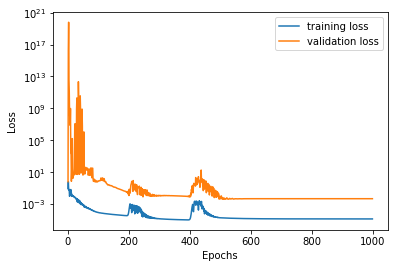

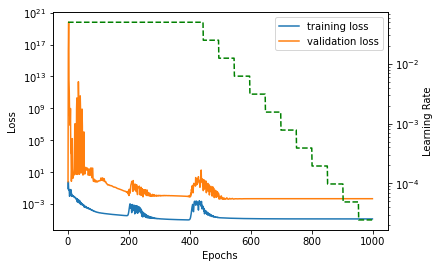

In [3]:
plt.figure()
plt.semilogy(range(len(train_loss)),train_loss,label='training loss')
plt.semilogy(range(len(val_loss)),val_loss,label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.savefig('Figures/trainingloss.png')

fig, ax2 = plt.subplots()
ax2.semilogy(range(len(train_loss)),train_loss,label='training loss')
ax2.semilogy(range(len(val_loss)),val_loss,label='validation loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
plt.legend()
ax = ax2.twinx()
ax.semilogy(epoch_list,lr_list,'g--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

plt.savefig('Figures/trainingloss_learningrate.png')

  0%|          | 0/1 [00:00<?, ?it/s]

Using dt of 0.050000000000000044


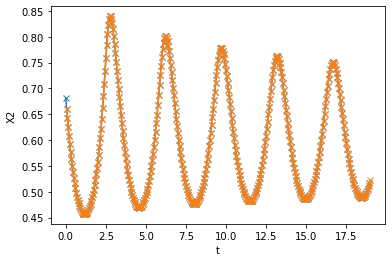

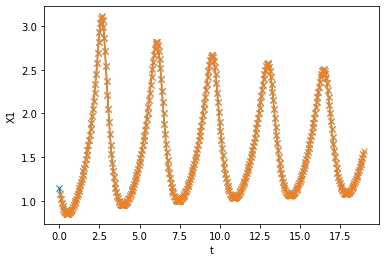

In [4]:
# Da = config["PAR"]["Da"]
Da = 0.28

dataset_test = CSTRDataset(1, config["DATA"]["TMAX"]*2,
                           config["DATA"]["L_TRAJECTORIES"]*2, 
                           Da=Da,
                           B=config["PAR"]["B"],
                           beta=config["PAR"]["beta"])

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(dataset_test.tt[:-1][dataset_test.x1[0]>0], dataset_test.x1[0][dataset_test.x1[0]>0], 'x-')
ax.plot(dataset_test.tt[1:][dataset_test.x1_out[0]>0], dataset_test.x1_out[0][dataset_test.x1_out[0]>0], 'x-')
ax.set_xlabel('t')
ax.set_ylabel('X2')
# plt.savefig(config["DATA"]["PATH"]+'test_data.pdf')
plt.show()
plt.close()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(dataset_test.tt[:-1], dataset_test.x2[0], 'x-')
ax.plot(dataset_test.tt[1:], dataset_test.x2_out[0], 'x-')
ax.set_xlabel('t')
ax.set_ylabel('X1')
plt.show()
plt.close()

In [5]:
print(dataset_test.x1[0][:10])
print(dataset_test.x1_out[0][:10])
print(dataset_test.x2[0][:10])
print(dataset_test.x2_out[0][:10])

[0.68052972 0.66104514 0.64242467 0.62470411 0.60790456 0.5920359
 0.57710352 0.56310835 0.55004571 0.53790617]
[0.66104514 0.64242467 0.62470411 0.60790456 0.5920359  0.57710352
 0.56310835 0.55004571 0.53790617 0.52667873]
[1.14994446 1.08156795 1.02471001 0.97807982 0.94049066 0.91086755
 0.88827906 0.87192373 0.86109236 0.85515558]
[1.08156795 1.02471001 0.97807982 0.94049066 0.91086755 0.88827906
 0.87192373 0.86109236 0.85515558 0.85357036]


In [6]:
network = Network(hidden_cells=config["MODEL"]["NUM_HIDDEN"],
                      tau = dataset_test.delta_t,
                      B=config["PAR"]["B"],
                      beta=config["PAR"]["beta"],
                      Da=config["PAR"]["Da"],
                      minmaxes=minmaxes
                     )
device = None
if torch.cuda.is_available() and device is None:
    device = 'cuda'
elif not torch.cuda.is_available() and device is None:
    device = 'cpu'
else:
    device = device

filename = config["DATA"]["PATH"]+'model_' +\
    '_hidden_layers_' +\
            str(len(network.hidden_cells))+'_'+str(network.hidden_cells[0])+'.net'

print(filename)
network.load_state_dict(torch.load(filename, map_location=torch.device(device)))

print(network)
network.to(device)

data/model__hidden_layers_1_64.net
Network(
  (sigmoid): RecursiveScriptModule(original_name=Sigmoid)
  (model): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=Snake)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=Snake)
    (4): RecursiveScriptModule(original_name=Linear)
  )
)


Network(
  (sigmoid): RecursiveScriptModule(original_name=Sigmoid)
  (model): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=Snake)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=Snake)
    (4): RecursiveScriptModule(original_name=Linear)
  )
)

In [ ]:
x1_out = []
x2_out = []
x1_out.append(dataset_test.x1[0][0])
x2_out.append(dataset_test.x2[0][0])

network = network.double()

warmup = 0
print(dataset_test.x1[0][:5])
print(dataset_test.x2[0][:5])

for i in range(dataset_test.x1[0].shape[0]):
    if i < warmup + 1:
        x1_in = torch.tensor(dataset_test.x1[0][i]).unsqueeze(0).unsqueeze(0).to(network.device)
        x2_in = torch.tensor(dataset_test.x2[0][i]).unsqueeze(0).unsqueeze(0).to(network.device)
        print('warming')
    else:
        x1_in = torch.tensor(x1_out[-1]).unsqueeze(0).unsqueeze(0).to(network.device)
        x2_in = torch.tensor(x2_out[-1]).unsqueeze(0).unsqueeze(0).to(network.device)
    
#     print(x1_in)
#     print(x2_in)
#     print(x1_in.shape)
#     print(x2_in.shape)
#     print(torch.tensor(dataset_test.Da).shape)
    x1, x2 = network(x1_in,x2_in,warmup=1,dt=torch.tensor(dataset_test.delta_t).to(network.device),
                    Da=torch.tensor(dataset_test.Da).unsqueeze(0).to(network.device),)
#     print(x1)
#     print(x2)
    x1_out.append(x1.detach().cpu().squeeze().numpy())
    x2_out.append(x2.detach().cpu().squeeze().numpy())
    
#     if i > 6: assert False

x1_out = np.array(x1_out[1:])
x2_out = np.array(x2_out[1:])
    
print('-------------')
print(x1_out[:10])
print(x2_out[:10])
print('-------------')
print(x1_out[-10:])
print(x2_out[-10:])

In [ ]:
plt.figure()
plt.plot(dataset_test.tt[1:],dataset_test.x1_out[0],'.-',label='true')
plt.plot(dataset_test.tt[1:],x1_out,'.-',label='predicted')

plt.figure()
plt.plot(dataset_test.tt[1:],dataset_test.x2_out[0],'.-',label='true')
plt.plot(dataset_test.tt[1:],x2_out,'.-',label='predicted')

In [ ]:
# print(len(x))

x1_in = torch.from_numpy(dataset_test.x1[0][:]).unsqueeze(0).to(network.device)
x2_in = torch.from_numpy(dataset_test.x2[0][:]).unsqueeze(0).to(network.device)
print(x1_in.shape)

x1_out, x2_out = network(x1_in,x2_in,warmup=0,dt=torch.tensor(dataset_test.delta_t).to(network.device),
                        Da=torch.tensor(dataset_test.Da).unsqueeze(-1).to(network.device),)
x1_out = x1_out.detach().cpu().squeeze().numpy()
x2_out = x2_out.detach().cpu().squeeze().numpy()

print(x1_out.shape)
print(dataset_test.x1[0][0])
print(dataset_test.x2[0][0])
print('-------------')
print(x1_out[:10])
print(x2_out[:10])
print('-------------')
print(x1_out[-10:])
print(x2_out[-10:])

In [ ]:
plt.figure()
plt.plot(dataset_test.tt[1:],dataset_test.x1_out[0],'.-',label='true')
plt.plot(dataset_test.tt[1:],x1_out,'.-',label='predicted')

plt.figure()
plt.plot(dataset_test.tt[1:],dataset_test.x2_out[0],'.-',label='true')
plt.plot(dataset_test.tt[1:],x2_out,'.-',label='predicted')